# Linked Dataset: Process, Property and Defect

The forms on the DMS are usually read one at a time, but they are joinable. Every form except NASA TTT records a sample IGSN, and following it links laser process parameters to fatigue results to the defects found on the fracture surface.

That join is the point of this notebook. It produces the one table in the archive that spans the full process–structure–property chain:

1. **Process** — ULI build parameters: laser power, scan velocity, hatch spacing
2. **Property** — four-point flexural fatigue: stress range and cycles to failure
3. **Defect** — fractography: size, type and location of the defect that caused failure

It closes with a coverage matrix showing which forms overlap, and which do not.

## Setup

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

REPO_ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "imqcam.py").exists())
sys.path.insert(0, str(REPO_ROOT))

from imqcam import (entries_to_frame, explode_records, extract_igsn, fetch_entries,
                    get_client, list_forms)

BLUE, ORANGE, GREEN, PURPLE = "#4C8BE2", "#E26C4C", "#4CE2A7", "#9B7CE2"

ULI = "68922e35f5b193b7d3e07f5b"
FLEXURAL = "68922e94f5b193b7d3e07f5c"
FRACTOGRAPHY = "69fa1d0872a32de5fe95028b"

client = get_client()
forms = list_forms(client)

# The overlap matrix needs every form, so each is pulled with its own targeted
# query and kept keyed by formId.
by_form = {
    form_id: fetch_entries(client, form_id=form_id, page_size=100)
    for form_id in forms
}

print(f"{sum(len(e) for e in by_form.values())} entries across {len(forms)} forms")

758 entries across 9 forms


## Which forms share samples

Before joining anything, it is worth seeing where the overlaps actually are. Each form contributes the set of IGSNs it mentions; the intersections show what can be linked.

In [2]:
igsn_sets = {}
for form_id, form_entries in by_form.items():
    found = {extract_igsn(e) for e in form_entries}
    found.discard(None)
    if found:
        igsn_sets[forms[form_id]] = found

names = sorted(igsn_sets, key=lambda n: -len(igsn_sets[n]))
overlap = pd.DataFrame(
    [[len(igsn_sets[a] & igsn_sets[b]) for b in names] for a in names],
    index=names,
    columns=names,
)
overlap

,Archival ULI Build (simplified),Four-point flexural test,Fractography Record,AM Build Parameters,Sample Heat Treatment Record,Printer Build
Archival ULI Build (simplified),192,192,72,0,0,0
Four-point flexural test,192,192,72,0,0,0
Fractography Record,72,72,72,0,0,0
AM Build Parameters,0,0,0,27,0,3
Sample Heat Treatment Record,0,0,0,0,9,1
Printer Build,0,0,0,3,1,7


Reading the diagonal gives each form's sample count; the off-diagonal gives the joinable population.

The important cells: **ULI and the flexural form share 192 samples**, and **fractography shares 72 with both**. Those 72 are the samples with process parameters, a fatigue result, and a measured defect.

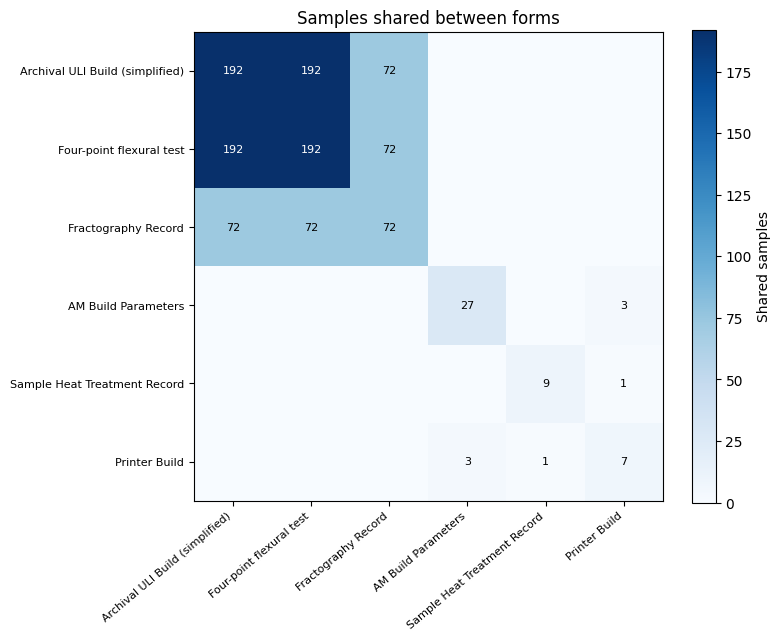

In [3]:
fig, ax = plt.subplots(figsize=(8, 6.5))
image = ax.imshow(overlap.values, cmap="Blues")
ax.set_xticks(range(len(names)))
ax.set_xticklabels(names, rotation=40, ha="right", fontsize=8)
ax.set_yticks(range(len(names)))
ax.set_yticklabels(names, fontsize=8)

for i in range(len(names)):
    for j in range(len(names)):
        value = overlap.values[i, j]
        if value:
            ax.text(j, i, str(value), ha="center", va="center", fontsize=8,
                    color="white" if value > overlap.values.max() / 2 else "black")

fig.colorbar(image, ax=ax, label="Shared samples")
ax.set_title("Samples shared between forms")
plt.tight_layout()
plt.show()

## NASA TTT cannot be joined

The largest single form on the DMS — 201 entries, and the only one carrying yield strength, elongation and modulus — records no IGSN at all. It identifies specimens by `Build_ID` and `Parameter_Label` instead.

This is worth being blunt about, because it is the most valuable mechanical dataset in the archive and it is currently stranded. Nothing below can include it.

In [4]:
NASA_TTT = "67d39472366ec49ab59dd4db"
ttt = entries_to_frame(by_form[NASA_TTT])

print(f"NASA TTT entries:        {len(ttt)}")
print(f"With a resolvable IGSN:  {ttt['igsn'].notna().sum()}")
print(f"\nIdentifiers it does carry: {[c for c in ttt.columns if 'ID' in c or 'Label' in c]}")
print(f"Example Build_ID:          {ttt['Build_ID'].iloc[0]}")

NASA TTT entries:        201
With a resolvable IGSN:  0

Identifiers it does carry: ['Build_ID', 'DOE_ID', 'Parameter_Label']
Example Build_ID:          A01_2022-01-01_JHUAPL_EOSM290_Ti64_Cylinder


## Process: ULI build parameters

One row per sample.

In [5]:
process = entries_to_frame(by_form[ULI])[
    ["igsn", "uniqueId", "buildId", "location", "projectName",
     "hatchSpacing", "scanPower", "scanVelocity"]
].rename(
    columns={
        "hatchSpacing": "hatchSpacing_mm",
        "scanPower": "laserPower_W",
        "scanVelocity": "laserVelocity_mm_s",
    }
)

for column in ("hatchSpacing_mm", "laserPower_W", "laserVelocity_mm_s"):
    process[column] = pd.to_numeric(process[column], errors="coerce")

print(f"{len(process)} ULI samples, {process['igsn'].nunique()} distinct IGSNs")
process.head()

192 ULI samples, 192 distinct IGSNs


,igsn,uniqueId,buildId,location,projectName,hatchSpacing_mm,laserPower_W,laserVelocity_mm_s
0,CMXMAL00011-01,CMU01.01,CMU01.01,CMU,ULI,0.14,370.0,950.0
1,CMXMAL00011-02,CMU01.02,CMU01.02,CMU,ULI,0.14,370.0,1150.0
2,CMXMAL00011-03,CMU01.03,CMU01.03,CMU,ULI,0.14,370.0,1150.0
3,CMXMAL00011-04,CMU01.04,CMU01.04,CMU,ULI,0.14,370.0,1100.0
4,CMXMAL00011-05,CMU01.05,CMU01.05,Tugce,ULI,0.14,370.0,800.0


## Property: fatigue results

One row per test, so a sample with three tests contributes three rows. The malformed rows identified in `02_flexural_fatigue.ipynb` are excluded here too.

In [6]:
fatigue = explode_records(by_form[FLEXURAL], "tests")
for column in ("cycles", "deltaSigma", "sigmaMaxInitiation", "pMax", "retestNumber"):
    fatigue[column] = pd.to_numeric(fatigue[column], errors="coerce")

usable = (
    (fatigue["pMax"] > 0)
    & (fatigue["deltaSigma"] > 0)
    & (fatigue["cycles"] > 0)
    & fatigue["igsn"].notna()
)
fatigue = fatigue.loc[usable].reset_index(drop=True)
fatigue["runout"] = fatigue["cycles"] >= 1e7

print(f"{len(fatigue)} usable tests across {fatigue['igsn'].nunique()} samples")
print(f"Run-outs: {fatigue['runout'].sum()}")

381 usable tests across 189 samples
Run-outs: 134


## Defect: worst defect per sample

Fatigue life is governed by the most severe defect, so each sample is reduced to its largest one.

In [7]:
defects = explode_records(by_form[FRACTOGRAPHY], "tests")
defects["rootArea"] = pd.to_numeric(defects["rootArea"], errors="coerce")
defects["surfaceClass"] = (
    defects["Surface_Subsurface"].fillna("").str.strip().str.lower().replace({"": None})
)

worst_defect = (
    defects.dropna(subset=["rootArea", "igsn"])
    .sort_values("rootArea", ascending=False)
    .groupby("igsn")
    .agg(
        maxRootArea=("rootArea", "first"),
        defectType=("Defect_Type", "first"),
        surfaceClass=("surfaceClass", "first"),
        defectCount=("rootArea", "size"),
    )
    .reset_index()
)

print(f"{len(worst_defect)} samples with measured defects")
worst_defect.head()

72 samples with measured defects


,igsn,maxRootArea,defectType,surfaceClass,defectCount
0,CMXMAL00011-01,30.448941,Keyhole,subsurface,2
1,CMXMAL00011-03,6.794042,Gas_Pore,subsurface,4
2,CMXMAL00011-05,39.522753,Keyhole,surface,3
3,CMXMAL00011-06,22.238323,Keyhole,surface,4
4,CMXMAL00011-08,56.921499,Keyhole,surface,4


## The join

Fatigue tests are the grain of the joined table: one row per test, with the sample's process parameters and worst defect attached. Left joins from fatigue outward, so a test is never dropped for lacking a defect measurement.

In [8]:
linked = (
    fatigue[["igsn", "uniqueId", "cycles", "deltaSigma", "sigmaMaxInitiation",
             "retestNumber", "runout"]]
    .merge(process.drop(columns=["uniqueId"]), on="igsn", how="left")
    .merge(worst_defect, on="igsn", how="left")
)

print(f"{len(linked)} rows, {linked['igsn'].nunique()} samples")
print(f"  with process parameters: {linked['laserPower_W'].notna().sum()}")
print(f"  with a measured defect:  {linked['maxRootArea'].notna().sum()}")
linked.head()

381 rows, 189 samples
  with process parameters: 378
  with a measured defect:  147


,igsn,uniqueId,cycles,deltaSigma,sigmaMaxInitiation,retestNumber,runout,buildId,location,projectName,hatchSpacing_mm,laserPower_W,laserVelocity_mm_s,maxRootArea,defectType,surfaceClass,defectCount
0,CMXMAL00011-01,CMU01.01,356846.0,960.3,1067.0,0.0,False,CMU01.01,CMU,ULI,0.14,370.0,950.0,30.448941,Keyhole,subsurface,2.0
1,CMXMAL00011-01,CMU01.01,7969454.0,810.0,900.0,0.0,False,CMU01.01,CMU,ULI,0.14,370.0,950.0,30.448941,Keyhole,subsurface,2.0
2,CMXMAL00011-02,CMU01.02,49396.0,1080.0,1200.0,0.0,False,CMU01.02,CMU,ULI,0.14,370.0,1150.0,NaN,NaN,NaN,NaN
3,CMXMAL00011-02,CMU01.02,10000000.0,960.3,1067.0,0.0,True,CMU01.02,CMU,ULI,0.14,370.0,1150.0,NaN,NaN,NaN,NaN
4,CMXMAL00011-02,CMU01.02,10000000.0,1080.0,1200.0,1.0,True,CMU01.02,CMU,ULI,0.14,370.0,1150.0,NaN,NaN,NaN,NaN


### Data overview

Each row is one fatigue test, enriched with the conditions that produced the specimen.

- **`igsn`** — the join key
- **`cycles`, `deltaSigma`, `sigmaMaxInitiation`** — the fatigue result
- **`runout`** — whether the test was stopped rather than failed
- **`laserPower_W`, `laserVelocity_mm_s`, `hatchSpacing_mm`** — the process condition
- **`maxRootArea`** — √area of the largest defect on the fracture surface (µm)
- **`defectType`, `surfaceClass`** — its mechanism and whether it broke the surface
- **`defectCount`** — how many defects were measured on that sample

## Verifying the join

The join is only trustworthy if the cardinalities are what the overlap matrix predicted.

In [9]:
checks = {
    "ULI samples": process["igsn"].nunique(),
    "Fatigue-tested samples": fatigue["igsn"].nunique(),
    "Samples with defects": worst_defect["igsn"].nunique(),
    "Fatigue rows keeping process params": int(linked["laserPower_W"].notna().sum()),
    "Fatigue rows with a defect": int(linked["maxRootArea"].notna().sum()),
    "Rows lost in the join": len(fatigue) - len(linked),
}
for label, value in checks.items():
    print(f"  {label:38s} {value}")

assert len(linked) == len(fatigue), "join changed the row count"
print("\nRow count preserved through both joins.")

  ULI samples                            192
  Fatigue-tested samples                 189
  Samples with defects                   72
  Fatigue rows keeping process params    378
  Fatigue rows with a defect             147
  Rows lost in the join                  0

Row count preserved through both joins.


## Defect size against fatigue life

The relationship the linked table exists to show. Run-outs are lower bounds, so they are drawn separately.

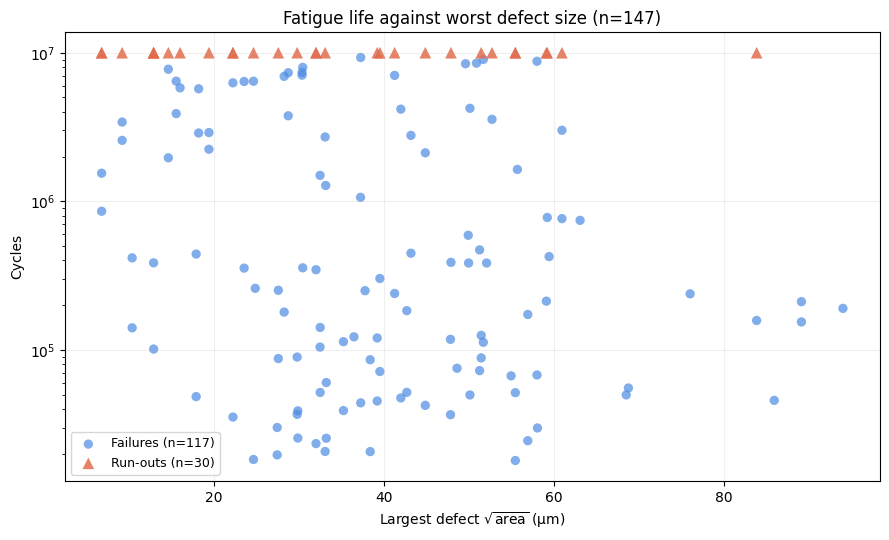

In [10]:
plot_data = linked.dropna(subset=["maxRootArea", "cycles"])
failures = plot_data[~plot_data["runout"]]
runouts = plot_data[plot_data["runout"]]

fig, ax = plt.subplots(figsize=(9, 5.5))
ax.scatter(failures["maxRootArea"], failures["cycles"], s=45, alpha=0.7, color=BLUE,
           label=f"Failures (n={len(failures)})", edgecolors="none")
if len(runouts):
    ax.scatter(runouts["maxRootArea"], runouts["cycles"], s=70, alpha=0.85, color=ORANGE,
               marker="^", label=f"Run-outs (n={len(runouts)})", edgecolors="none")

ax.set_yscale("log")
ax.set_xlabel(r"Largest defect $\sqrt{\mathrm{area}}$ (µm)")
ax.set_ylabel("Cycles")
ax.set_title(f"Fatigue life against worst defect size (n={len(plot_data):,})")
ax.legend(fontsize=9)
ax.grid(alpha=0.2)
plt.tight_layout()
plt.show()

## Process against defect size

The other half of the chain: whether the laser parameters predict the defect population they produce.

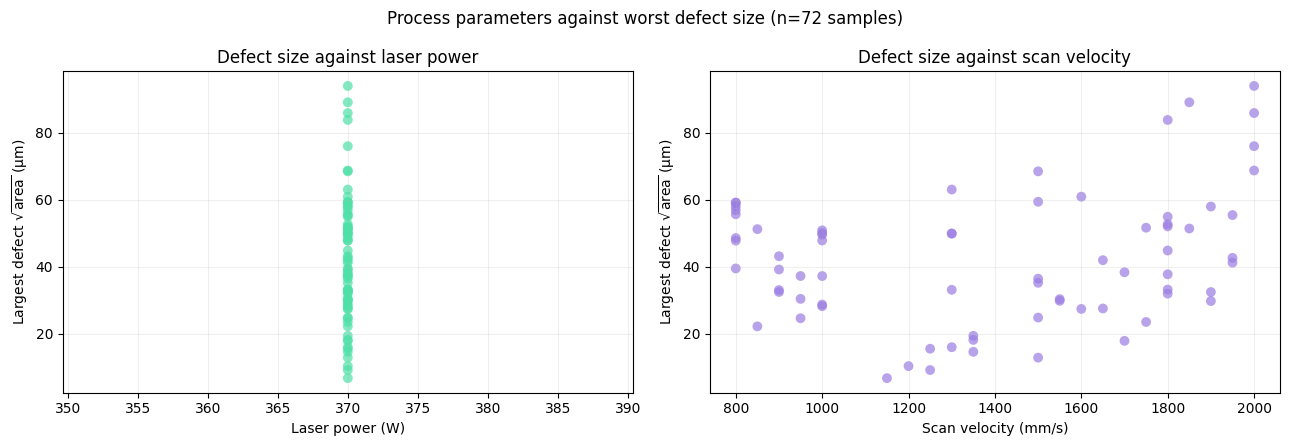

In [11]:
process_defect = linked.dropna(subset=["maxRootArea", "laserPower_W", "laserVelocity_mm_s"])
per_sample = process_defect.groupby("igsn").first().reset_index()

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

axes[0].scatter(per_sample["laserPower_W"], per_sample["maxRootArea"], s=50, alpha=0.7,
                color=GREEN, edgecolors="none")
axes[0].set_xlabel("Laser power (W)")
axes[0].set_ylabel(r"Largest defect $\sqrt{\mathrm{area}}$ (µm)")
axes[0].set_title("Defect size against laser power")
axes[0].grid(alpha=0.2)

axes[1].scatter(per_sample["laserVelocity_mm_s"], per_sample["maxRootArea"], s=50, alpha=0.7,
                color=PURPLE, edgecolors="none")
axes[1].set_xlabel("Scan velocity (mm/s)")
axes[1].set_ylabel(r"Largest defect $\sqrt{\mathrm{area}}$ (µm)")
axes[1].set_title("Defect size against scan velocity")
axes[1].grid(alpha=0.2)

fig.suptitle(f"Process parameters against worst defect size (n={len(per_sample)} samples)")
plt.tight_layout()
plt.show()

## Correlations

Pairwise correlations over the numeric columns of the linked table, restricted to failures — including run-outs would bias every correlation involving `cycles`, since their true life is unknown.

Complete failure rows for correlation: 117


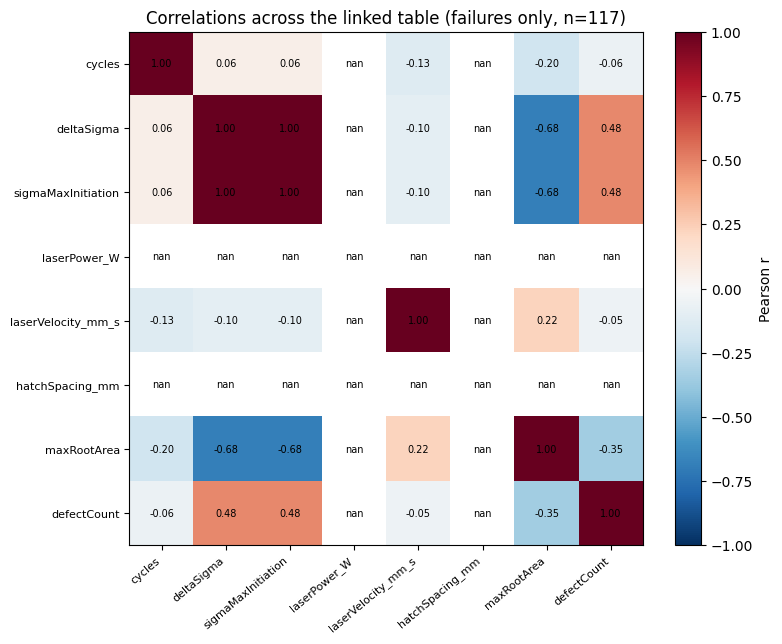

In [12]:
numeric_columns = ["cycles", "deltaSigma", "sigmaMaxInitiation", "laserPower_W",
                   "laserVelocity_mm_s", "hatchSpacing_mm", "maxRootArea", "defectCount"]
correlation_input = linked.loc[~linked["runout"], numeric_columns].dropna()

print(f"Complete failure rows for correlation: {len(correlation_input)}")
correlations = correlation_input.corr().round(2)

fig, ax = plt.subplots(figsize=(8, 6.5))
image = ax.imshow(correlations.values, cmap="RdBu_r", vmin=-1, vmax=1)
ax.set_xticks(range(len(numeric_columns)))
ax.set_xticklabels(numeric_columns, rotation=40, ha="right", fontsize=8)
ax.set_yticks(range(len(numeric_columns)))
ax.set_yticklabels(numeric_columns, fontsize=8)
for i in range(len(numeric_columns)):
    for j in range(len(numeric_columns)):
        ax.text(j, i, f"{correlations.values[i, j]:.2f}", ha="center", va="center",
                fontsize=7)
fig.colorbar(image, ax=ax, label="Pearson r")
ax.set_title(f"Correlations across the linked table (failures only, n={len(correlation_input)})")
plt.tight_layout()
plt.show()

## Coverage summary

What the linked table does and does not cover, as a caveat list for anyone modelling on it.

In [13]:
summary = pd.DataFrame(
    [
        {"quantity": "Fatigue tests", "rows": len(linked)},
        {"quantity": "Distinct samples", "rows": linked["igsn"].nunique()},
        {"quantity": "With process parameters", "rows": int(linked["laserPower_W"].notna().sum())},
        {"quantity": "With a measured defect", "rows": int(linked["maxRootArea"].notna().sum())},
        {"quantity": "Failures (usable for life models)",
         "rows": int((~linked["runout"]).sum())},
        {"quantity": "Run-outs (censored)", "rows": int(linked["runout"].sum())},
        {"quantity": "Complete rows, all three domains",
         "rows": len(linked.dropna(subset=["laserPower_W", "maxRootArea", "cycles"]))},
    ]
)
summary

,quantity,rows
0,Fatigue tests,381
1,Distinct samples,189
2,With process parameters,378
3,With a measured defect,147
4,Failures (usable for life models),247
5,Run-outs (censored),134
6,"Complete rows, all three domains",147


Three caveats carry forward to any model built on this table:

- **Run-outs are censored.** Roughly a third of tests were stopped at 10⁷ cycles rather than failing. Treating them as failures understates life; dropping them biases toward the low-life tail. They need survival-style handling.
- **Process parameters barely vary.** The ULI archive records a single hatch spacing and a narrow band of powers and velocities, so the process side of the correlation matrix is close to constant by construction. Weak correlations there are a property of the sampling, not evidence that process does not matter.
- **Retests are not independent.** Specimens with `retestNumber > 0` were previously cycled, so their recorded life is conditional on having survived earlier loading.